#### Imports

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import zscore
import pingouin as pg
from scipy.stats import shapiro, kstest, anderson
from statsmodels.stats.diagnostic import lilliefors, het_goldfeldquandt
import joblib

#### Ingestão dos dados

In [2]:
df = pd.read_csv('Dataset - Colesterol.csv',sep=',')

In [3]:
df.head()

,Id,Grupo Sanguíneo,Fumante,Nível de Atividade,Idade,Peso,Altura,Colesterol
0,1,B,Sim,Baixo,33.0,85.1,186.0,199.63
1,2,A,Não,Moderado,68.0,105.0,184.0,236.98
2,3,O,Não,Alto,25.0,64.8,180.0,161.79
3,4,A,Não,Alto,43.0,120.2,167.0,336.24
4,5,AB,Não,Baixo,79.0,88.5,175.0,226.23


In [4]:
#alterando o nome das colunas
df.columns = [
    'id',
    'grupo_sanguineo',
    'fumante',
    'nivel_atividade_fisica',
    'idade',
    'peso',
    'altura',
    'colesterol'
]

In [5]:
df.drop(axis=0,columns='id',inplace=True)

#### Limpeza e análise exploratória dos dados

##### Limpeza

In [6]:
df_eda = df.copy()
df_bucketing = df.copy()

In [7]:
df_eda.head()

,grupo_sanguineo,fumante,nivel_atividade_fisica,idade,peso,altura,colesterol
0,B,Sim,Baixo,33.0,85.1,186.0,199.63
1,A,Não,Moderado,68.0,105.0,184.0,236.98
2,O,Não,Alto,25.0,64.8,180.0,161.79
3,A,Não,Alto,43.0,120.2,167.0,336.24
4,AB,Não,Baixo,79.0,88.5,175.0,226.23


In [8]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   grupo_sanguineo         996 non-null    str    
 1   fumante                 997 non-null    str    
 2   nivel_atividade_fisica  996 non-null    str    
 3   idade                   997 non-null    float64
 4   peso                    997 non-null    float64
 5   altura                  997 non-null    float64
 6   colesterol              1000 non-null   float64
dtypes: float64(4), str(3)
memory usage: 54.8 KB


In [9]:
df_eda.describe()

,idade,peso,altura,colesterol
count,997.000000,997.000000,997.000000,1000.000000
mean,49.206620,76.496690,174.889669,199.453260
std,17.476704,21.439132,8.844703,50.625152
min,20.000000,15.400000,160.000000,36.260000
25%,34.000000,61.700000,167.000000,166.345000
50%,49.000000,75.500000,175.000000,199.455000
75%,65.000000,90.200000,183.000000,233.785000
max,79.000000,158.100000,190.000000,372.670000


In [10]:
for coluna in df_eda.columns:
    print(coluna,  df_eda[coluna].unique(),sep='\n')

grupo_sanguineo
<StringArray>
['B', 'A', 'O', 'AB', nan]
Length: 5, dtype: str
fumante
<StringArray>
['Sim', 'Não', nan]
Length: 3, dtype: str
nivel_atividade_fisica
<StringArray>
['Baixo', 'Moderado', 'Alto', nan]
Length: 4, dtype: str
idade
[33. 68. 25. 43. 79. 60. 35. 62. 44. 57. 52. 22. 20. 36. 34. 28. 26. 78.
 51. 21. 64. 59. 77. 47. 27. 24. 37. 67. 65. 30. 41. 63. 46. nan 72. 69.
 50. 54. 45. 61. 23. 73. 76. 55. 71. 48. 32. 38. 40. 70. 42. 66. 31. 53.
 75. 58. 39. 49. 56. 74. 29.]
peso
[ 85.1 105.   64.8 120.2  88.5  66.8 117.3  86.9  81.3  32.7 123.6  78.4
 105.8  75.4  85.9  55.3 102.   62.1 109.6  92.4  75.  100.4 112.5  79.7
 111.2  52.3  24.8  76.5  59.   68.9  64.3  87.4  78.   53.1 102.9 114.9
  78.2  74.8  67.8  88.1 101.   55.9  88.7  89.3  86.  104.5  68.1  97.1
 135.7  61.9 107.9  87.9  68.   80.8  94.8 107.2  68.8  61.3  91.1  66.3
  47.2  73.5  85.2  43.3  76.6 111.4  64.   77.2 135.   35.2  36.5  34.5
  72.9  65.4  77.   93.2  38.1  84.6  81.   85.8  97.6  53.6  86.

In [11]:
df_eda.isna().sum()

grupo_sanguineo           4
fumante                   3
nivel_atividade_fisica    4
idade                     3
peso                      3
altura                    3
colesterol                0
dtype: int64

In [12]:
df_eda.describe()

,idade,peso,altura,colesterol
count,997.000000,997.000000,997.000000,1000.000000
mean,49.206620,76.496690,174.889669,199.453260
std,17.476704,21.439132,8.844703,50.625152
min,20.000000,15.400000,160.000000,36.260000
25%,34.000000,61.700000,167.000000,166.345000
50%,49.000000,75.500000,175.000000,199.455000
75%,65.000000,90.200000,183.000000,233.785000
max,79.000000,158.100000,190.000000,372.670000


In [13]:
grupo_sanguineo_mode = df_eda['grupo_sanguineo'].mode()
fumante_mode = df_eda['fumante'].mode()
nivel_atividade_fisica_mode = df_eda['nivel_atividade_fisica'].mode()
idade_median = df_eda['idade'].median()
peso_median = df_eda['peso'].median()
altura_median = df_eda['altura'].median()

In [14]:
df_eda.head()

,grupo_sanguineo,fumante,nivel_atividade_fisica,idade,peso,altura,colesterol
0,B,Sim,Baixo,33.0,85.1,186.0,199.63
1,A,Não,Moderado,68.0,105.0,184.0,236.98
2,O,Não,Alto,25.0,64.8,180.0,161.79
3,A,Não,Alto,43.0,120.2,167.0,336.24
4,AB,Não,Baixo,79.0,88.5,175.0,226.23


In [15]:
df_eda.fillna(value={'grupo_sanguineo': grupo_sanguineo_mode[0],
                     'fumante': fumante_mode[0],
                     'nivel_atividade_fisica': nivel_atividade_fisica_mode[0],
                     'idade': idade_median,
                     'peso': peso_median,
                     'altura': altura_median
                     },inplace=True)

,grupo_sanguineo,fumante,nivel_atividade_fisica,idade,peso,altura,colesterol
0,B,Sim,Baixo,33.0,85.1,186.0,199.63
1,A,Não,Moderado,68.0,105.0,184.0,236.98
2,O,Não,Alto,25.0,64.8,180.0,161.79
3,A,Não,Alto,43.0,120.2,167.0,336.24
4,AB,Não,Baixo,79.0,88.5,175.0,226.23
...,...,...,...,...,...,...,...
995,AB,Sim,Moderado,31.0,68.1,166.0,206.81
996,O,Não,Alto,51.0,47.7,170.0,128.03
997,AB,Não,Baixo,39.0,85.5,176.0,211.14
998,AB,Sim,Baixo,61.0,91.2,161.0,284.53


In [16]:
df_eda.isna().sum()

grupo_sanguineo           0
fumante                   0
nivel_atividade_fisica    0
idade                     0
peso                      0
altura                    0
colesterol                0
dtype: int64

In [17]:
#convertendo idade e altura para int
df_eda['idade'] = df_eda['idade'].astype(int)
df_eda['altura'] = df_eda['altura'].astype(int)

In [18]:
df_eda.describe()

,idade,peso,altura,colesterol
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.206000,76.493700,174.890000,199.453260
std,17.450446,21.406986,8.831415,50.625152
min,20.000000,15.400000,160.000000,36.260000
25%,34.000000,61.775000,167.000000,166.345000
50%,49.000000,75.500000,175.000000,199.455000
75%,64.250000,89.975000,183.000000,233.785000
max,79.000000,158.100000,190.000000,372.670000


##### Análise Exploratória

<Axes: ylabel='idade'>

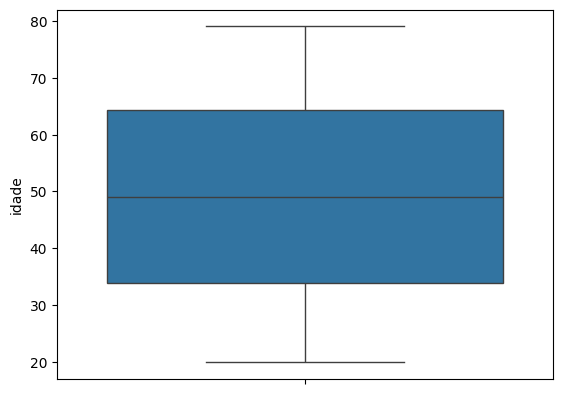

In [19]:
sns.boxplot(df_eda['idade'])

<Axes: ylabel='peso'>

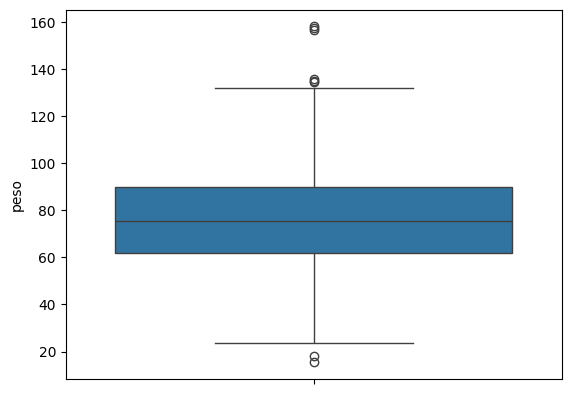

In [20]:
sns.boxplot(df_eda['peso'])

<Axes: xlabel='peso', ylabel='Count'>

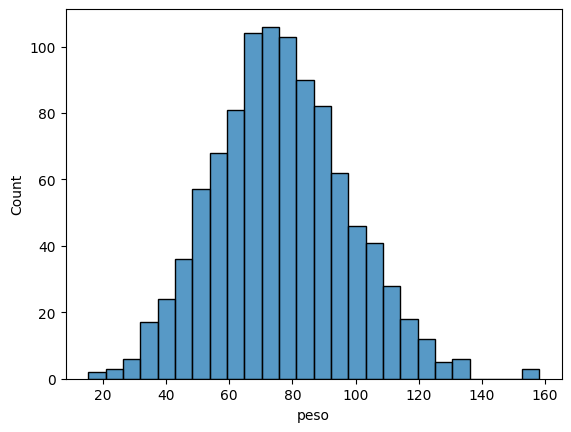

In [21]:
sns.histplot(df_eda['peso'])

In [22]:
#Removendo pessoas com peso abaixo de 50Kg

df_eda = df_eda[df_eda['peso'] > 40]

<Axes: ylabel='altura'>

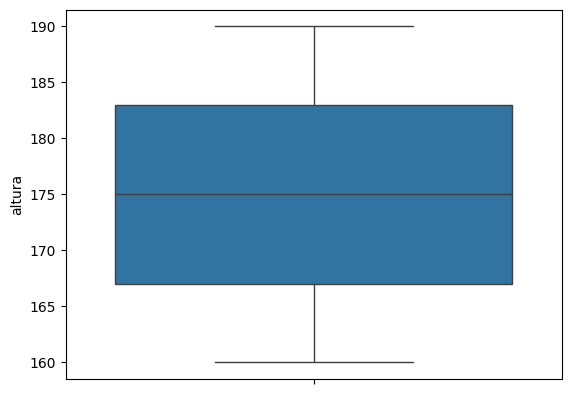

In [23]:
sns.boxplot(df_eda['altura'])

<Axes: ylabel='colesterol'>

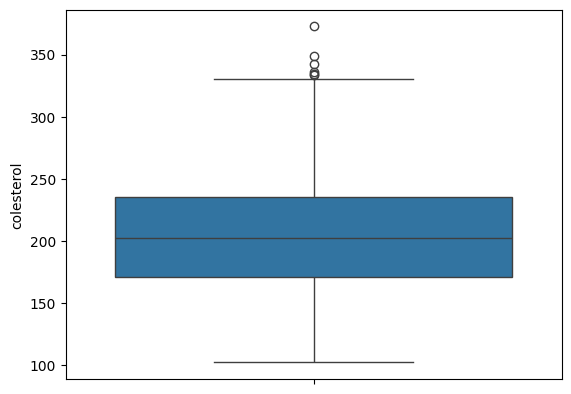

In [24]:
sns.boxplot(df_eda['colesterol'])

<Axes: xlabel='colesterol', ylabel='Count'>

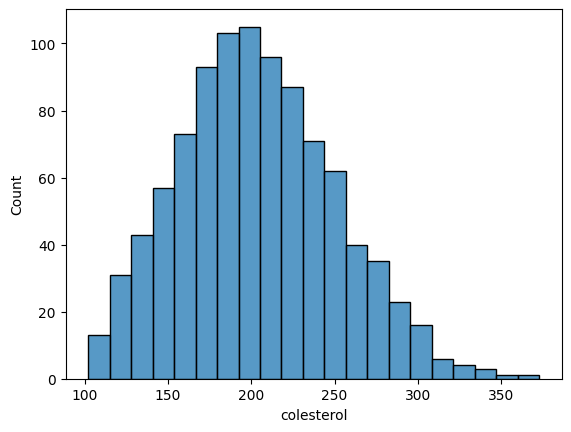

In [25]:
sns.histplot(df_eda['colesterol'])

<Axes: xlabel='grupo_sanguineo', ylabel='colesterol'>

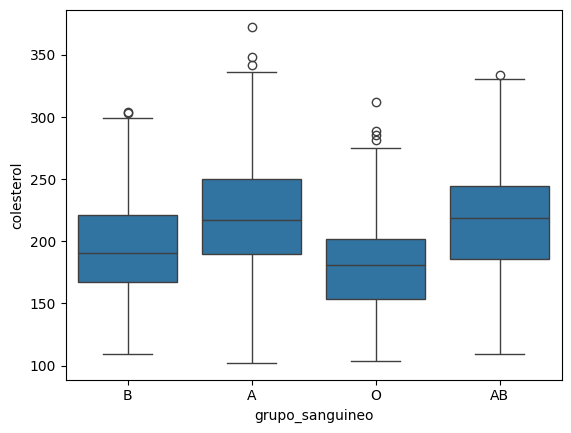

In [26]:
#cruzamento de variáveis categóricas com nível de colesterol
sns.boxplot(data=df_eda,x='grupo_sanguineo',y='colesterol')

<Axes: xlabel='fumante', ylabel='colesterol'>

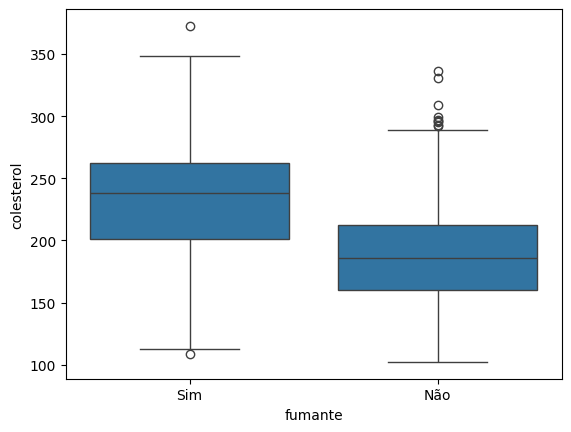

In [27]:
sns.boxplot(data=df_eda,x='fumante',y='colesterol')

<Axes: xlabel='nivel_atividade_fisica', ylabel='colesterol'>

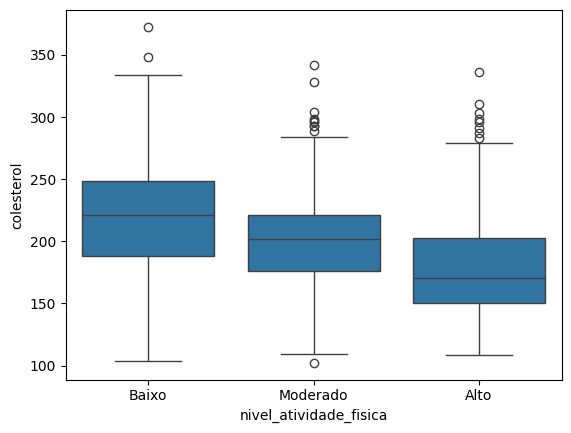

In [28]:
sns.boxplot(data=df_eda,x='nivel_atividade_fisica',y='colesterol')

<Axes: xlabel='idade', ylabel='colesterol'>

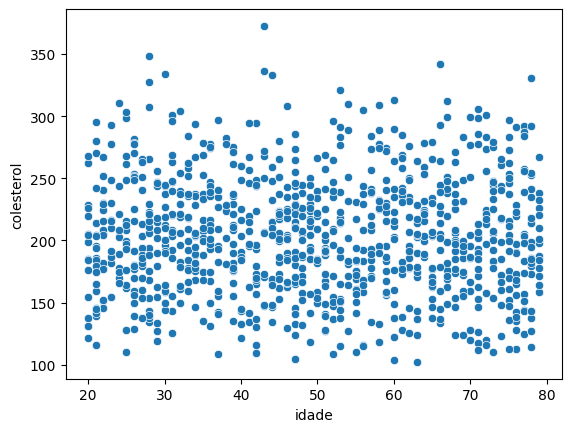

In [29]:
sns.scatterplot(data=df_eda,x='idade',y='colesterol')

<Axes: xlabel='altura', ylabel='colesterol'>

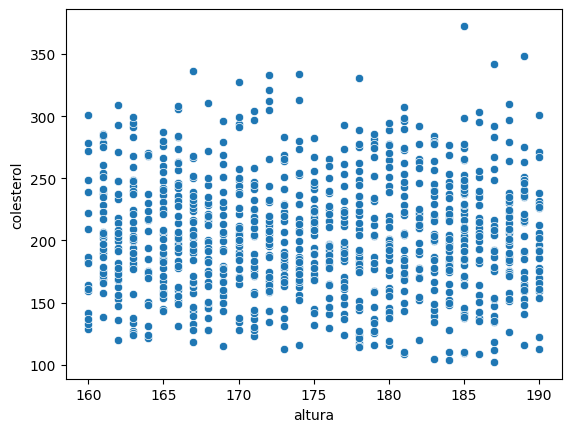

In [30]:
sns.scatterplot(data=df_eda,x='altura',y='colesterol')

<Axes: xlabel='peso', ylabel='colesterol'>

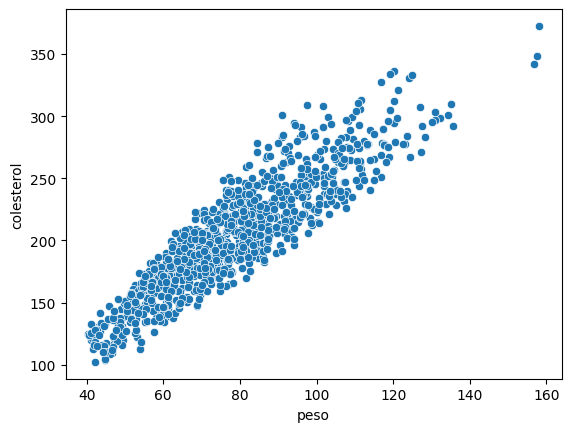

In [31]:
sns.scatterplot(data=df_eda,x='peso',y='colesterol')

In [32]:
df_eda['peso_x_altura'] = df_eda['peso']/df_eda['altura']
df_eda.head()

,grupo_sanguineo,fumante,nivel_atividade_fisica,idade,peso,altura,colesterol,peso_x_altura
0,B,Sim,Baixo,33,85.1,186,199.63,0.457527
1,A,Não,Moderado,68,105.0,184,236.98,0.570652
2,O,Não,Alto,25,64.8,180,161.79,0.360000
3,A,Não,Alto,43,120.2,167,336.24,0.719760
4,AB,Não,Baixo,79,88.5,175,226.23,0.505714


<Axes: xlabel='peso_x_altura', ylabel='colesterol'>

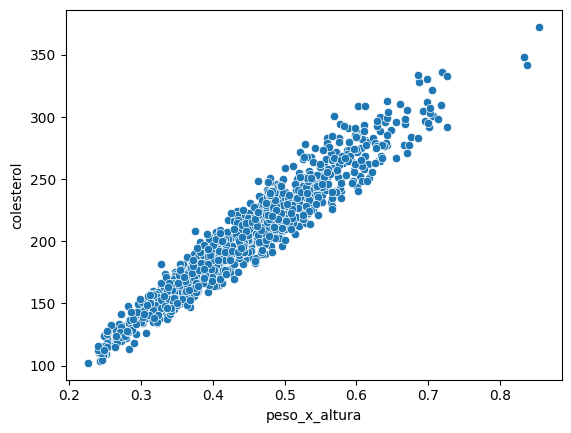

In [33]:
sns.scatterplot(data=df_eda,x='peso_x_altura',y='colesterol')

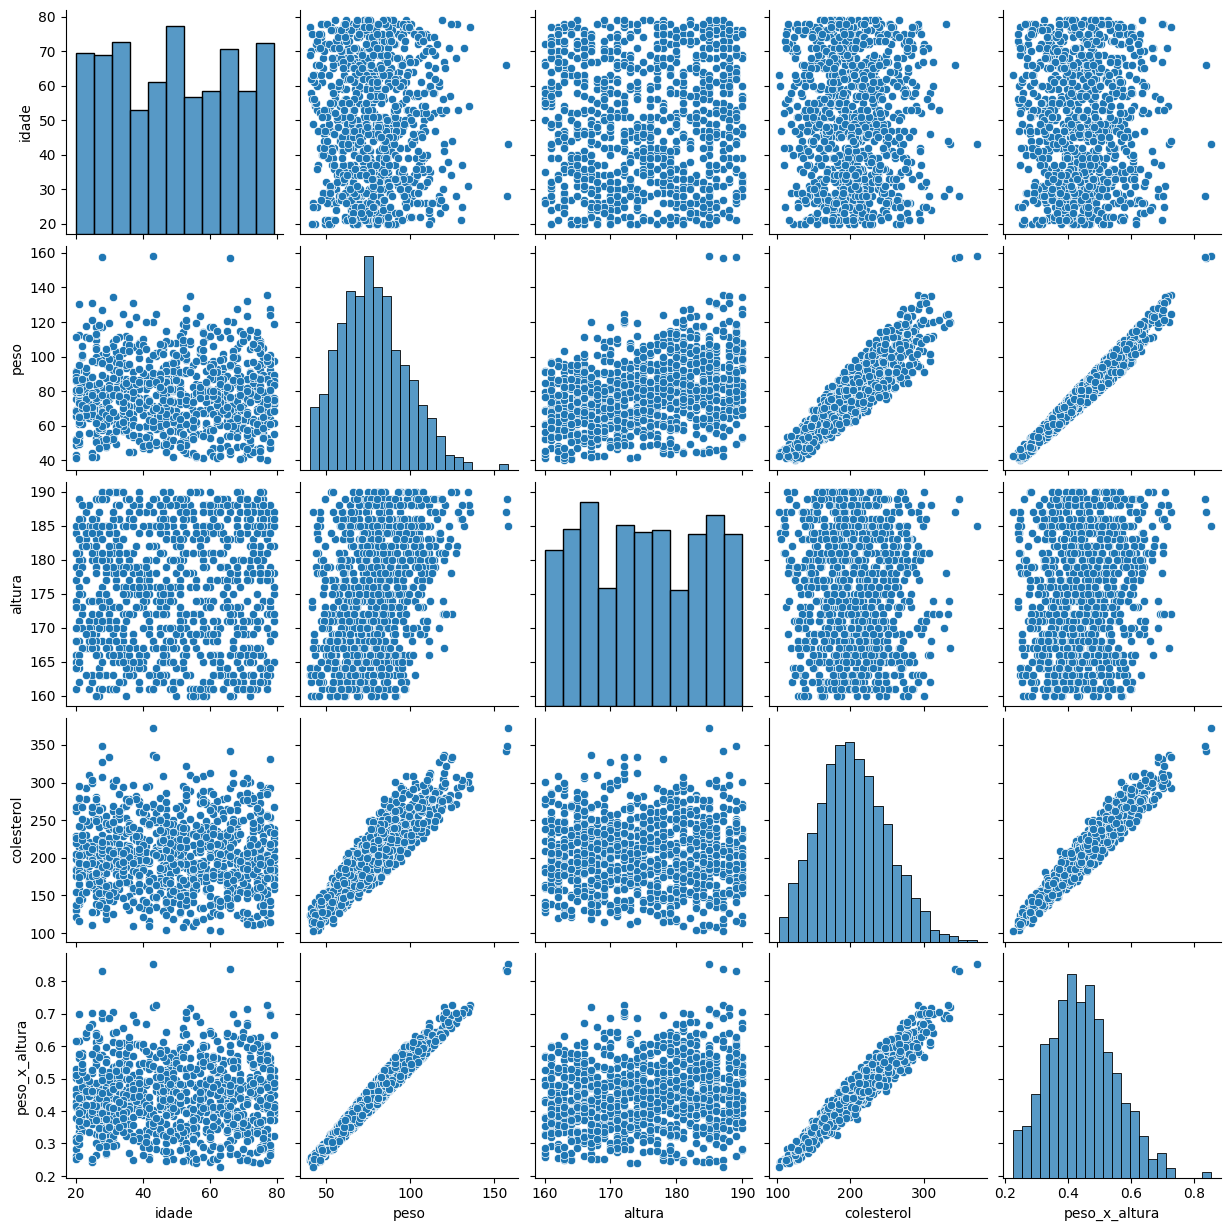

In [34]:
sns.pairplot(df_eda)

Objetivo: realizar uma análise de correlação entre as variáveis do dataset <br>
Problema: existem variáveis categóricas <br>
Categóricas nominais: realização do one-hot enconding com o get_dummies <br>
Categóricas ordinais: substituição dos valores ordinais por variável numérica através do factorize

In [35]:
df_eda.head()

,grupo_sanguineo,fumante,nivel_atividade_fisica,idade,peso,altura,colesterol,peso_x_altura
0,B,Sim,Baixo,33,85.1,186,199.63,0.457527
1,A,Não,Moderado,68,105.0,184,236.98,0.570652
2,O,Não,Alto,25,64.8,180,161.79,0.360000
3,A,Não,Alto,43,120.2,167,336.24,0.719760
4,AB,Não,Baixo,79,88.5,175,226.23,0.505714


In [36]:
df_eda = pd.get_dummies(data=df_eda, columns=['grupo_sanguineo','fumante'],dtype='int64')

In [37]:
df_eda['nivel_atividade_fisica'] = pd.factorize(df_eda['nivel_atividade_fisica'])[0] + 1

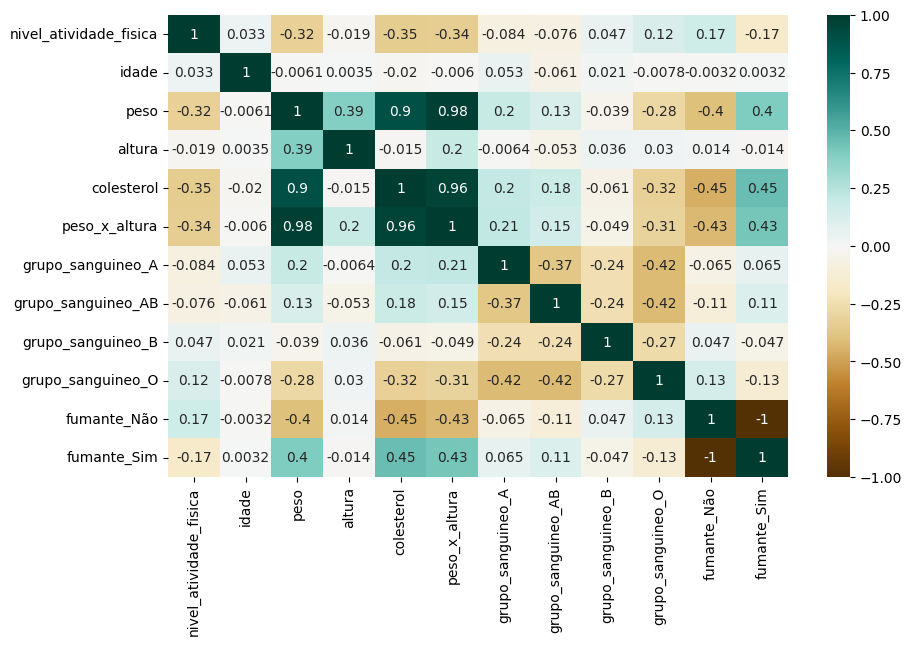

In [38]:
corr = df_eda.corr('pearson')
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='BrBG')
plt.show()

<Axes: >

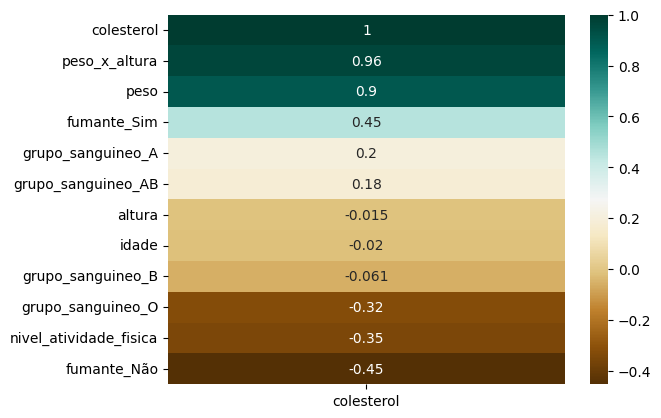

In [39]:
sns.heatmap(corr[['colesterol']].sort_values(by='colesterol',ascending=False),annot=True,cmap='BrBG')

bucketing

In [40]:
bins_idade = []
inicial = 20
final = 80
while inicial <= final:
    bins_idade.append(inicial)
    inicial += 10
labels_idade = ['20-29','30-39','40-49','50- 59','60-69','70-79',]
df_bucketing['faixa_idade'] = pd.cut(x = df_bucketing['idade'],bins=bins_idade, labels=labels_idade,include_lowest=True)


In [41]:
bins_peso = []
inicial = 10
final = 160
while inicial <= final:
    bins_peso.append(inicial)
    inicial += 10
labels_peso = ['10-19','20-29','30-39','40-49','50- 59','60-69','70-79','80-89','90-99','100-109','110-119','120-129','130-139','140-149','150-159']
df_bucketing['faixa_peso'] = pd.cut(x = df_bucketing['peso'],bins=bins_peso, labels=labels_peso,include_lowest=True)


In [42]:
df_bucketing.head(10)

,grupo_sanguineo,fumante,nivel_atividade_fisica,idade,peso,altura,colesterol,faixa_idade,faixa_peso
0,B,Sim,Baixo,33.0,85.1,186.0,199.63,30-39,80-89
1,A,Não,Moderado,68.0,105.0,184.0,236.98,60-69,100-109
2,O,Não,Alto,25.0,64.8,180.0,161.79,20-29,60-69
3,A,Não,Alto,43.0,120.2,167.0,336.24,40-49,120-129
4,AB,Não,Baixo,79.0,88.5,175.0,226.23,70-79,80-89
5,B,Não,Baixo,68.0,66.8,170.0,185.31,60-69,60-69
6,A,Sim,Baixo,60.0,117.3,181.0,289.33,50- 59,110-119
7,O,Sim,Moderado,35.0,86.9,174.0,216.48,30-39,80-89
8,O,Não,Baixo,62.0,81.3,166.0,235.30,60-69,80-89
9,B,Sim,Alto,44.0,32.7,165.0,97.79,40-49,30-39


<Axes: xlabel='faixa_idade', ylabel='colesterol'>

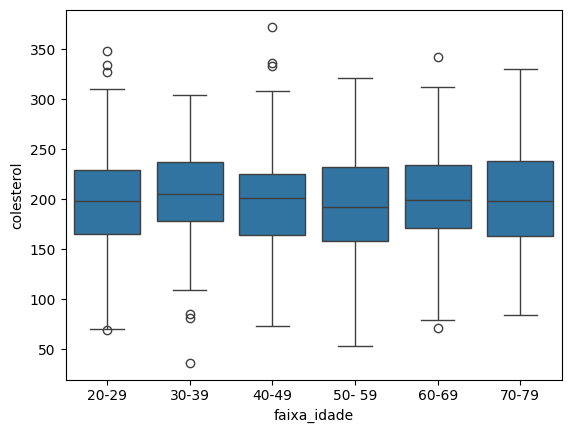

In [43]:
sns.boxplot(df_bucketing, x='faixa_idade',y='colesterol')

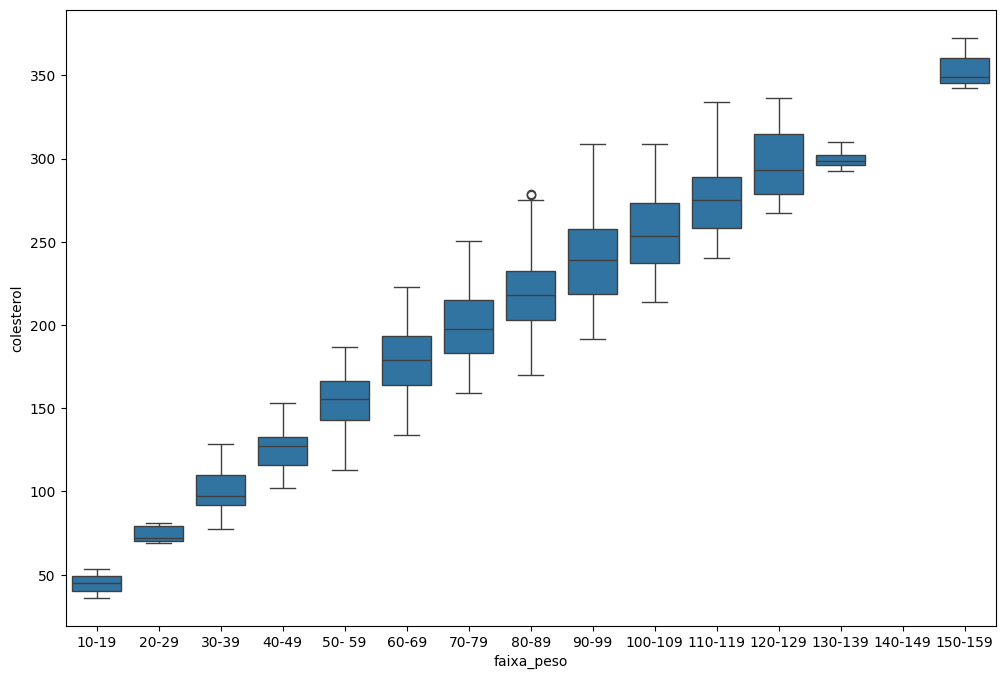

In [44]:
plt.figure(figsize=(12,8))
sns.boxplot(df_bucketing, x='faixa_peso',y='colesterol')
plt.show()

#### Training the model

In [45]:
df_eda.head()

,nivel_atividade_fisica,idade,peso,altura,colesterol,peso_x_altura,grupo_sanguineo_A,grupo_sanguineo_AB,grupo_sanguineo_B,grupo_sanguineo_O,fumante_Não,fumante_Sim
0,1,33,85.1,186,199.63,0.457527,0,0,1,0,0,1
1,2,68,105.0,184,236.98,0.570652,1,0,0,0,1,0
2,3,25,64.8,180,161.79,0.360000,0,0,0,1,1,0
3,3,43,120.2,167,336.24,0.719760,1,0,0,0,1,0
4,1,79,88.5,175,226.23,0.505714,0,1,0,0,1,0


In [46]:
X = df.drop(columns=['colesterol'])
y = df['colesterol']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=575,test_size=0.3)

In [48]:
df.head()

,grupo_sanguineo,fumante,nivel_atividade_fisica,idade,peso,altura,colesterol
0,B,Sim,Baixo,33.0,85.1,186.0,199.63
1,A,Não,Moderado,68.0,105.0,184.0,236.98
2,O,Não,Alto,25.0,64.8,180.0,161.79
3,A,Não,Alto,43.0,120.2,167.0,336.24
4,AB,Não,Baixo,79.0,88.5,175.0,226.23


In [49]:
#Contruindo pipeline de transformação dos dados

#Variáveis categóricas (nominais e ordinais): imputar a moda (grupo_sanguineo,fumante,nivel_atividade_fisica)
#Variáveis numéricas: padronização de escala (idade,peso,altura)
#Onehotencoding nas variáveis categóricas nominais (grupo_sanguineo,fumante)
#Ordinalencoding nas variáveis categóricas nominais (nivel_atividade_fisica)
#Imputar mediana nas variáveis numéricas (idade,peso,altura)

colunas_categoricas_nominais = ['grupo_sanguineo','fumante']
colunas_numericas = ['idade','peso','altura']
colunas_categoricas_ordinais = ['nivel_atividade_fisica']

In [50]:
transformer_categorias = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [51]:
transformer_numericas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [52]:
transformer_ordinais = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[['Baixo', 'Moderado', 'Alto']]
    ))
])

In [53]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', transformer_numericas, colunas_numericas),
        ('cat', transformer_categorias, colunas_categoricas_nominais),
        ('ord', transformer_ordinais, colunas_categoricas_ordinais)
    ]
)

In [54]:
modelo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [55]:
modelo.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

#### Análise de métricas

In [56]:
y_pred = modelo.predict(X_test)

In [57]:
#r2 score
r2_score(y_test,y_pred)

0.9645278740258195

In [58]:
#mean absolute error (MAE)
mean_absolute_error(y_test,y_pred)

7.523226414143461

In [59]:
#Root Mean Squared Error RMSE
mean_squared_error(y_test,y_pred)

91.43973104091067

#### Análise de resíduos

In [60]:
residuos = y_test - y_pred

In [61]:
redisuos_std = zscore(residuos)

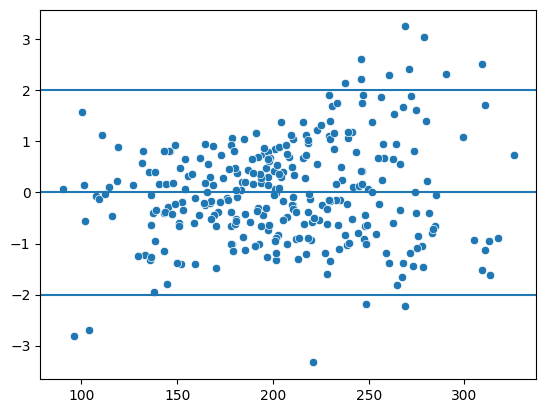

In [62]:
sns.scatterplot(x=y_pred,y=redisuos_std)
plt.axhline(y=0)
plt.axhline(y=2)
plt.axhline(y=-2)
plt.show()

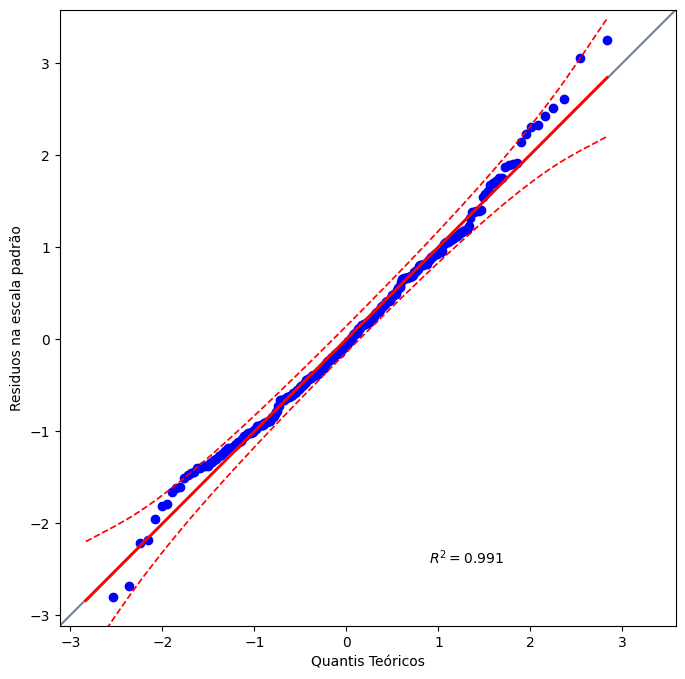

In [63]:
#checar se residuos seguem uma distribuição normal
plt.figure(figsize=(14,8))
pg.qqplot(redisuos_std,dist='norm',confidence=0.95)
plt.xlabel('Quantis Teóricos')
plt.ylabel('Residuos na escala padrão')
plt.show()

In [64]:
#Teste de normalidade de Shapiro-Wilk
stat_shapiro, p_value_shapiro = shapiro(residuos)
print('Estatística do teste: {} e P-value {}'.format(stat_shapiro,p_value_shapiro))

Estatística do teste: 0.992485705326813 e P-value 0.1346688866013957


In [65]:
#Teste de Kolmogorov
stat_ks, p_value_ks = kstest(residuos,'norm')
print('Estatística do teste: {} e P-value {}'.format(stat_ks,p_value_ks))

Estatística do teste: 0.4244146330057198 e P-value 1.5376568643128228e-49


In [66]:
#Teste de Lilliefors
stat_ll, p_value_ll = lilliefors(residuos,dist='norm',pvalmethod='table')
print('Estatística do teste: {} e P-value {}'.format(stat_ll,p_value_ll))

Estatística do teste: 0.03143159930593242 e P-value 0.7461446541756118


In [67]:
#Teste de Anderson Dailing
stat_and, critical_and, significance_and = anderson(residuos,dist='norm')

C:\Users\yurio\AppData\Local\Temp\ipykernel_71136\460359000.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  stat_and, critical_and, significance_and = anderson(residuos,dist='norm')


In [68]:
significance_and

array([15. , 10. ,  5. ,  2.5,  1. ])

In [69]:
print('Estatística do teste: {} e valor crítico {}'.format(stat_and,critical_and[2]))

Estatística do teste: 0.5209961412618895 e valor crítico 0.75


In [75]:
#testando um input aleatório
sample = {
    'grupo_sanguineo': 'B',
    'fumante': 'Não',
    'nivel_atividade_fisica': 'Alto',
    'idade': 29,
    'peso': 100,
    'altura': 183,
}
sample_df = pd.DataFrame(sample, index=[1])

In [80]:
modelo.predict(sample_df)

array([237.84584355])

In [81]:
joblib.dump(modelo,'./modelo.pkl')

['./modelo.pkl']